In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/cleaned_retail.csv"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [2]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [3]:
df["Revenue"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

In [4]:
daily_sales = (
    df.groupby(
        df["InvoiceDate"].dt.date
    )["Revenue"]
    .sum()
)

daily_sales.head()

InvoiceDate
2010-12-01    45867.26
2010-12-02    45656.47
2010-12-03    22553.38
2010-12-05    30970.28
2010-12-06    30258.77
Name: Revenue, dtype: float64

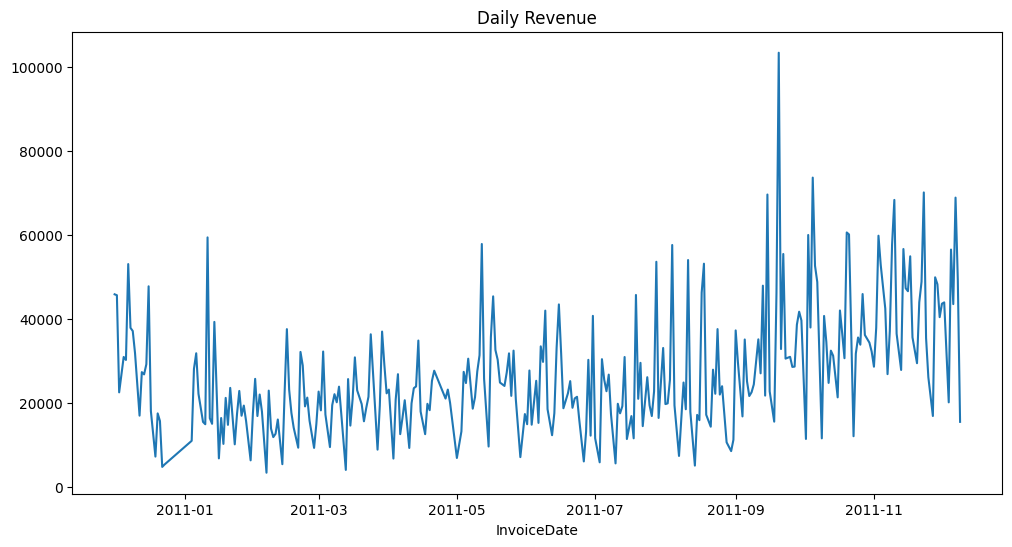

In [5]:
import matplotlib.pyplot as plt

daily_sales.plot(
    figsize=(12,6)
)

plt.title("Daily Revenue")

plt.show()

In [6]:
monthly_sales = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

monthly_sales

InvoiceDate
2010-12     552372.860
2011-01     473731.900
2011-02     435534.070
2011-03     578576.210
2011-04     425222.671
2011-05     647011.670
2011-06     606862.520
2011-07     573112.321
2011-08     615078.090
2011-09     929356.232
2011-10     973306.380
2011-11    1126815.070
2011-12     341539.430
Freq: M, Name: Revenue, dtype: float64

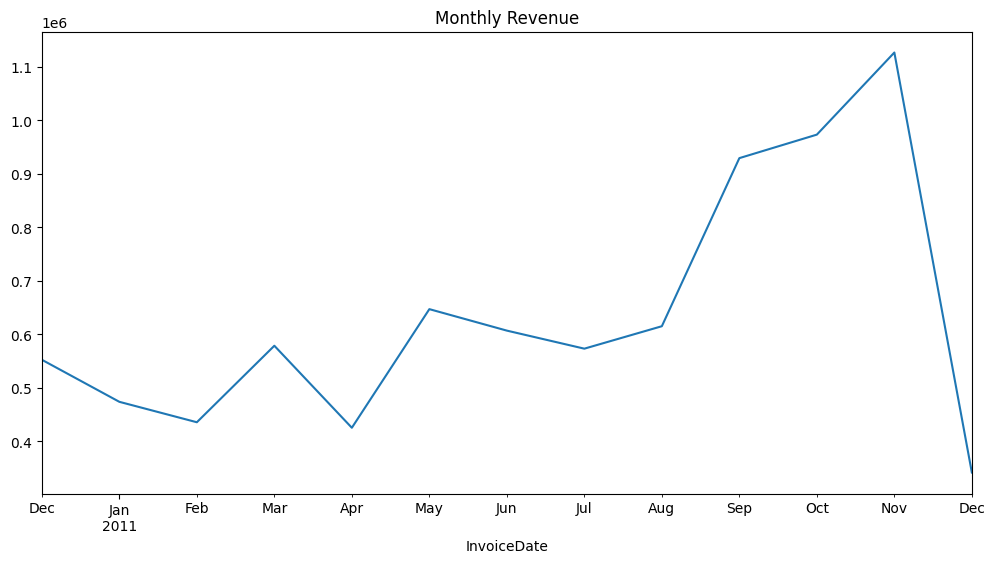

In [7]:
monthly_sales.plot(
    figsize=(12,6)
)

plt.title("Monthly Revenue")

plt.show()

In [8]:
daily_sales.to_csv(
    "../data/processed/daily_sales.csv"
)

In [9]:
from statsmodels.tsa.stattools import adfuller

In [10]:
result = adfuller(daily_sales)

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -1.2435991215409208
P-value: 0.6545650745327614


<Axes: xlabel='InvoiceDate'>

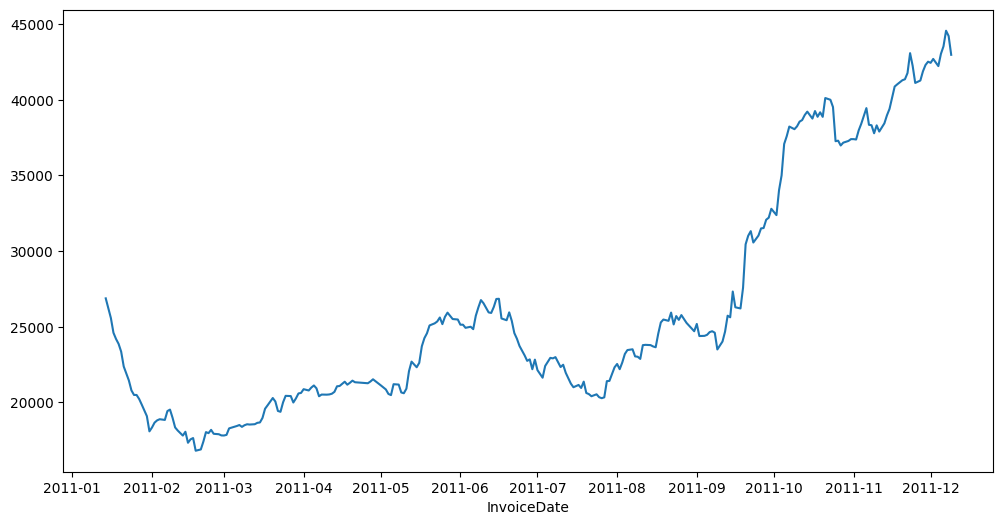

In [11]:
rolling_mean = daily_sales.rolling(
    window=30
).mean()

rolling_mean.plot(
    figsize=(12,6)
)

<Axes: xlabel='InvoiceDate'>

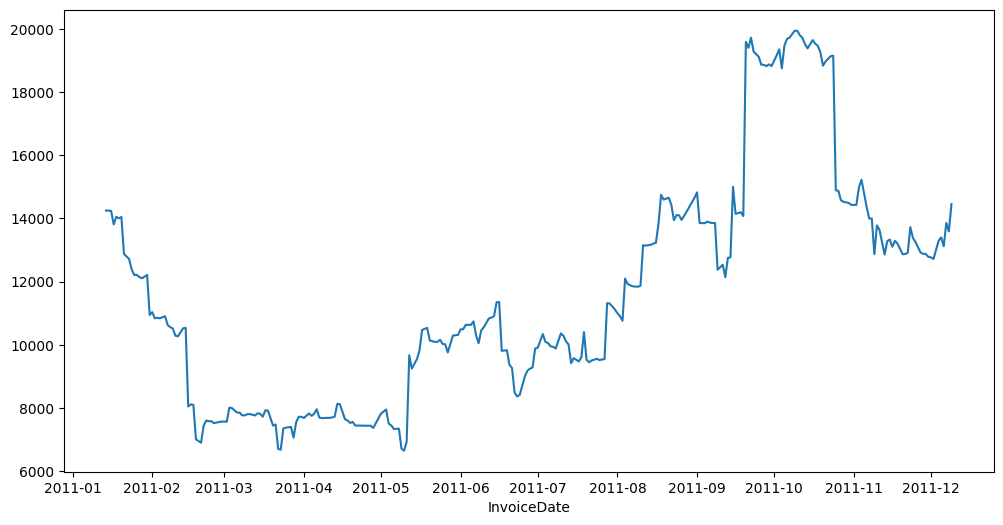

In [12]:
rolling_std = daily_sales.rolling(
    window=30
).std()

rolling_std.plot(
    figsize=(12,6)
)

In [1]:
import pandas as pd

daily_sales = pd.read_csv(
    "../data/processed/daily_sales.csv"
)

daily_sales.head()

,InvoiceDate,Revenue
0,2010-12-01,45867.26
1,2010-12-02,45656.47
2,2010-12-03,22553.38
3,2010-12-05,30970.28
4,2010-12-06,30258.77


In [2]:
daily_sales["InvoiceDate"] = pd.to_datetime(
    daily_sales["InvoiceDate"]
)

daily_sales.head()

,InvoiceDate,Revenue
0,2010-12-01,45867.26
1,2010-12-02,45656.47
2,2010-12-03,22553.38
3,2010-12-05,30970.28
4,2010-12-06,30258.77


In [3]:
prophet_df = daily_sales.rename(
    columns={
        "InvoiceDate":"ds",
        "Revenue":"y"
    }
)

prophet_df.head()

,ds,y
0,2010-12-01,45867.26
1,2010-12-02,45656.47
2,2010-12-03,22553.38
3,2010-12-05,30970.28
4,2010-12-06,30258.77


In [4]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_df)

Importing plotly failed. Interactive plots will not work.
13:38:28 - cmdstanpy - INFO - Chain [1] start processing
13:38:28 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
future = model.make_future_dataframe(
    periods=30
)

future.tail()

,ds
330,2012-01-04
331,2012-01-05
332,2012-01-06
333,2012-01-07
334,2012-01-08


In [6]:
forecast = model.predict(future)

forecast[["ds","yhat"]].tail()

,ds,yhat
330,2012-01-04,49127.665382
331,2012-01-05,56249.233625
332,2012-01-06,44950.924669
333,2012-01-07,60193.606314
334,2012-01-08,36300.854558


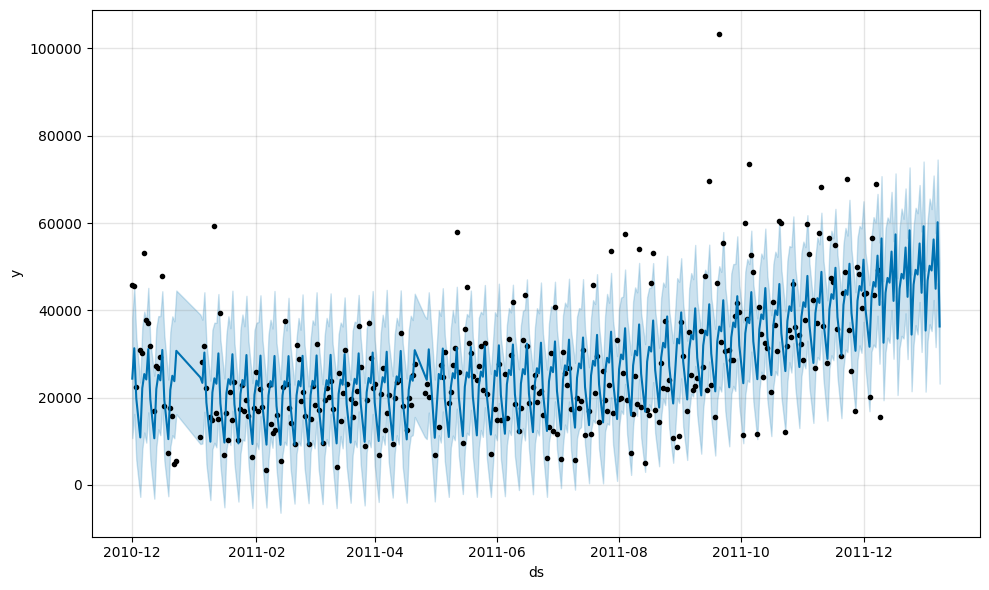

In [7]:
fig = model.plot(forecast)

In [8]:
forecast[["ds","yhat"]].to_csv(
    "../data/processed/forecast_30_days.csv",
    index=False
)

In [9]:
from joblib import dump

dump(
    model,
    "../models/prophet_model.joblib"
)

['../models/prophet_model.joblib']